# Customer Segmentation using RFM Analysis & K-Means

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Point 1 & 2: RFM Calculation & Scaling

In [ ]:
import os
# 1. Read the dataset automatically
file_path = '01-ml-project/retail_transactions_segmentation.csv' if os.path.exists('01-ml-project/retail_transactions_segmentation.csv') else 'retail_transactions_segmentation.csv'
df = pd.read_csv(file_path)

In [ ]:
import os

# 1. Read the dataset
file_path = (
    "01-ml-project/retail_transactions_segmentation.csv"
    if os.path.exists("01-ml-project/retail_transactions_segmentation.csv")
    else "retail_transactions_segmentation.csv"
)
df = pd.read_csv(file_path)
# Convert transaction date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# 2. Set the reference date
reference_date = df["transaction_date"].max() + pd.Timedelta(days=1)

# 3. Calculate RFM for each customer
rfm = df.groupby("customer_id").agg(
    Recency=("transaction_date",
             lambda x: (reference_date - x.max()).days),
    Frequency=("transaction_date", "count"),
    Monetary=("amount", "sum")
).reset_index()

# 4. Standardize the RFM features
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled_values = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled_values,
    columns=["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]
)

# 5. Combine original RFM and scaled RFM
final_rfm = pd.concat([rfm, rfm_scaled], axis=1)

# 6. Save the final dataset for the K-Means team member
final_rfm.to_csv("RFM_Scaled_Customer_Segmentation.csv", index=False)

print("RFM & Scaling completed successfully!")
print("Number of customers:", len(final_rfm))
final_rfm.head()


RFM & Scaling completed successfully!
Number of customers: 300


,customer_id,Recency,Frequency,Monetary,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,5001,2,16,5172.45,-0.772792,0.356692,-0.113196
1,5002,23,18,6158.98,-0.464634,0.544920,-0.010898
2,5003,37,3,654.12,-0.259195,-0.866790,-0.581723
3,5004,5,35,31050.88,-0.728770,2.144859,2.570262
4,5005,26,16,5700.91,-0.420611,0.356692,-0.058397


# Read Data

In [ ]:
df = pd.read_csv("RFM_Scaled_Customer_Segmentation.csv")
df.head()


,customer_id,Recency,Frequency,Monetary,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,5001,2,16,5172.45,-0.772792,0.356692,-0.113196
1,5002,23,18,6158.98,-0.464634,0.544920,-0.010898
2,5003,37,3,654.12,-0.259195,-0.866790,-0.581723
3,5004,5,35,31050.88,-0.728770,2.144859,2.570262
4,5005,26,16,5700.91,-0.420611,0.356692,-0.058397


# Specifying Features

In [ ]:
import pandas as pd
df = pd.read_csv("RFM_Scaled_Customer_Segmentation.csv")

features = [
    "Recency_Scaled",
    "Frequency_Scaled",
    "Monetary_Scaled"
]

X = df[features]
X.head()

,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


# Point 3: Optimal K Selection - Elbow Method

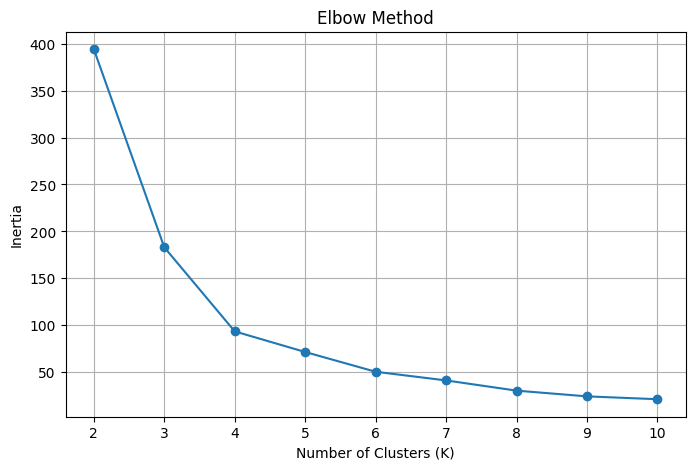

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Elbow drawing
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.grid(True)
plt.show()


# Silhouette Score

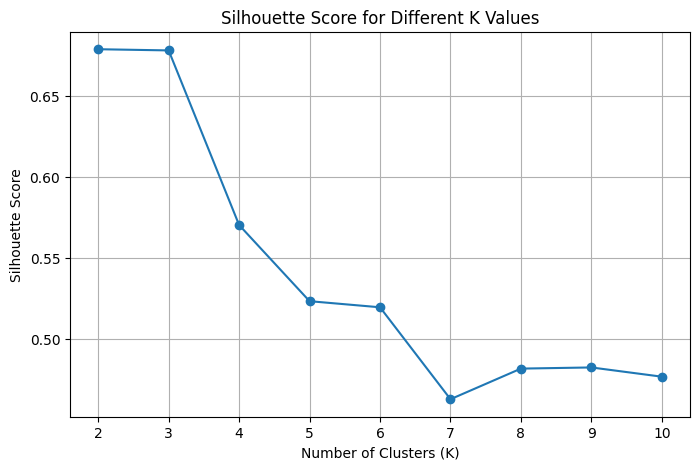

Highest Silhouette K: 2
Best Silhouette Score: 0.6789101247002551


,K,Inertia,Silhouette Score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


In [ ]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Definition of optimal K (by highest score, for reference)
best_k_by_score = K_range[np.argmax(silhouette_scores)]
print("Highest Silhouette K:", best_k_by_score)
print("Best Silhouette Score:", max(silhouette_scores))

# Results table
results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})
results



#Optimal K Selection:

Based on the Elbow Method and Silhouette Score, K = 3 was selected as the optimal number of clusters. The Silhouette Score for K = 3 (0.678) is very close to the highest score at K = 2 (0.680), while the Elbow curve shows that the decrease in inertia becomes less significant after K = 3. Therefore, K = 3 provides a good balance between clustering quality and the number of clusters.

# Point 4: K-Means Clustering

In [ ]:
# تحديد أفضل عدد للـ Clusters بناءً على نتائج الـ Elbow والـ Silhouette
best_k = 3
print('Selected K:',best_k )
# إنشاء موديل K-Means باستخدام عدد الـ Clusters المختار
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# تدريب الموديل وتحديد الـ Cluster لكل عميل
df["Cluster"] = kmeans.fit_predict(X)

print("K-Means clustering completed successfully!")
print(df["Cluster"].value_counts().sort_index())



Selected K: 3
K-Means clustering completed successfully!
Cluster
0     40
1    238
2     22
Name: count, dtype: int64


# Point 5: PCA Visualization

Percentage of information retained by each component:
PC1: 75.03%
PC2: 23.72%

Total information retained: 98.75%


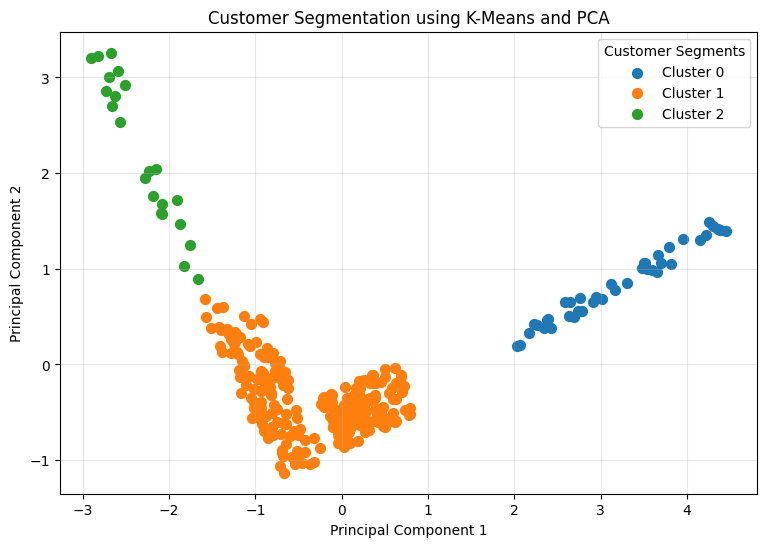

,count
Cluster,
0,40
1,238
2,22


In [ ]:
# تقليل عدد الأبعاد من 3 Features إلى بُعدين فقط
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"].values
pca_df.head()

# Explained Variance
explained_variance = pca.explained_variance_ratio_
print("Percentage of information retained by each component:")
print(f"PC1: {explained_variance[0]:.2%}")
print(f"PC2: {explained_variance[1]:.2%}")
print(f"\nTotal information retained: {explained_variance.sum():.2%}")

# Cluster Visualization
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        s=50,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means and PCA")
plt.legend(title="Customer Segments")
plt.grid(True, alpha=0.3)
plt.show()

df["Cluster"].value_counts().sort_index()

# Point 6: Customer Personas & Business Recommendations

In [ ]:
# Calculate average RFM values for each cluster
cluster_profile = df.groupby("Cluster")[[
    "Recency", "Frequency", "Monetary"
]].mean().round(2)

# Assign a persona to each cluster
personas = {
    0: "VIP / High-Value Loyal Customers",
    1: "Regular / Potential Customers",
    2: "At-Risk / Low-Value Customers"
}

cluster_profile["Persona"] = cluster_profile.index.map(personas)
cluster_profile

,Recency,Frequency,Monetary,Persona
Cluster,,,,
0,8.40,35.00,29683.61,VIP / High-Value Loyal Customers
1,43.59,9.32,2876.90,Regular / Potential Customers
2,258.59,2.09,326.14,At-Risk / Low-Value Customers


### Marketing Analysis

- **Cluster 0 – VIP / High-Value Loyal Customers:** Recent, frequent, and high-spending customers.
- **Cluster 1 – Regular / Potential Customers:** Customers with moderate purchasing activity and spending.
- **Cluster 2 – At-Risk / Low-Value Customers:** Customers who have not purchased recently and have low purchasing activity and spending.

### Business Recommendations

- **Cluster 0:** VIP rewards, exclusive offers, and personalized recommendations.
- **Cluster 1:** Personalized promotions, cross-selling, and loyalty incentives.
- **Cluster 2:** Win-back campaigns, personalized discounts, and limited-time offers.

### Conclusion

RFM segmentation helps identify customer value and enables targeted marketing strategies for each segment.
